##### Setup

###### 1. Importações

In [1]:
# Bibliotecas padrão do Python
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence, Union

# Bibliotecas para cálculos numéricos
import numpy as np
import pandas as pd

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv

# Bibliotecas para manipulação de imagens
from PIL import Image, ImageDraw

# Bibliotecas para exibição no Jupyter Notebook
from IPython.display import HTML, display

###### 2. Exibição de imagens

In [2]:
# Funções de exibição reutilizadas pelas Questões 1 a 4.
def exibir_imagem(eixo, imagem, titulo, maximo_cinza=None, mostrar_eixos=False):
    """Exibe uma imagem RGB/RGBA ou uma matriz em cinza num eixo existente."""
    dados = np.asarray(imagem)
    if maximo_cinza is None:
        eixo.imshow(dados)
    else:
        eixo.imshow(dados, cmap="gray", vmin=0, vmax=maximo_cinza,
                    interpolation="nearest")
    eixo.set_title(titulo)
    if mostrar_eixos:
        eixo.set(xlabel="x (pixels)", ylabel="y (pixels)")
    else:
        eixo.axis("off")


def exibir_paineis(paineis, figsize=(16, 4), mostrar_eixos=False):
    fig, eixos = plt.subplots(1, len(paineis), figsize=figsize)
    for eixo, (imagem, titulo, maximo_cinza) in zip(eixos, paineis):
        exibir_imagem(eixo, imagem, titulo, maximo_cinza, mostrar_eixos)
    plt.tight_layout()
    plt.show()

###### 3. Normalização e conversão RGB

In [3]:
def normalizar_canal(canal):
    menor, maior = float(np.min(canal)), float(np.max(canal))
    if maior - menor < 1e-12:
        return np.zeros_like(canal, dtype=np.float64)  # matriz constante vira preto
    return (canal - menor) / (maior - menor)


def rgb_float_para_imagem(rgb):
    """Converte RGB em [0, 1] para uma imagem Pillow de 8 bits."""
    pixels = np.rint(np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    return Image.fromarray(pixels, "RGB")

##### QUESTÃO1 

###### 1.

In [4]:
@dataclass
class Circulo:
    centro: tuple[int, int]
    raio: int
    tom: int = 110
    alfa: int = 190


@dataclass
class Reta:
    inicio: tuple[int, int]
    fim: tuple[int, int]
    tom: int = 20
    alfa: int = 255
    largura: int = 3


@dataclass
class Poligono:
    vertices: list[tuple[int, int]]
    tom: int = 80
    alfa: int = 165

###### 2. 

In [5]:
Descritor = Union[Circulo, Reta, Poligono]


def renderizar(descritores: Sequence[Descritor], tamanho=(100, 100)):
    base = Image.new("RGBA", tamanho, (255, 255, 255, 255))
    camadas = []

    for forma in descritores:
        camada = Image.new("RGBA", tamanho, (0, 0, 0, 0))
        pincel = ImageDraw.Draw(camada)
        cor = (forma.tom, forma.tom, forma.tom, forma.alfa)

        if isinstance(forma, Circulo):
            cx, cy = forma.centro
            r = forma.raio
            pincel.ellipse((cx-r, cy-r, cx+r, cy+r), fill=cor)
        elif isinstance(forma, Reta):
            pincel.line((forma.inicio, forma.fim), fill=cor, width=forma.largura)
        elif isinstance(forma, Poligono):
            if len(forma.vertices) < 3:
                raise ValueError("Um polígono precisa de pelo menos 3 vértices.")
            pincel.polygon(forma.vertices, fill=cor)
        else:
            raise TypeError(f"Descritor desconhecido: {type(forma).__name__}")

        camadas.append(camada)
        base = Image.alpha_composite(base, camada)

    return base.convert("L"), base, camadas

###### 3.

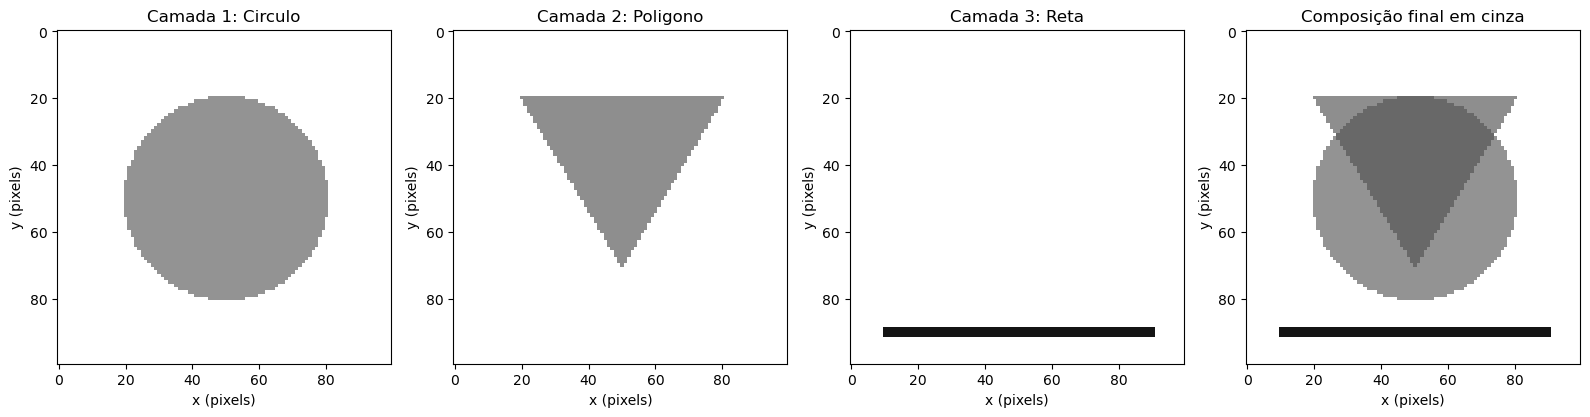

In [6]:
cena = [
    Circulo(centro=(50, 50), raio=30),
    Poligono(vertices=[(20, 20), (80, 20), (50, 70)]),
    Reta(inicio=(10, 90), fim=(90, 90)),
]

imagem_cinza, imagem_rgba, camadas = renderizar(cena)
imagem_cinza.save("questao1_bitmap_cinza.png")

fundo = Image.new("RGBA", imagem_rgba.size, "white")
paineis_q1 = [
    (Image.alpha_composite(fundo, camada).convert("L"),
     f"Camada {i}: {type(forma).__name__}", 255)
    for i, (forma, camada) in enumerate(zip(cena, camadas), start=1)
]
paineis_q1.append((imagem_cinza, "Composição final em cinza", 255))
exibir_paineis(paineis_q1, mostrar_eixos=True)

##### QUESTÃO2

###### 1.

In [7]:
# Carregar imagem

USAR_UPLOAD_COLAB = False
CAMINHO_IMAGEM = Path("Archives/images.jpeg")

if USAR_UPLOAD_COLAB:
    try:
        from google.colab import files
    except ImportError as erro:
        raise RuntimeError("A opção de upload requer Google Colab.") from erro
    enviados = files.upload()
    if not enviados:
        raise ValueError("Nenhuma imagem foi enviada.")
    caminho = Path(next(iter(enviados)))
else:
    caminho = Path(CAMINHO_IMAGEM)

if not caminho.is_file():
    raise FileNotFoundError(f"Imagem não encontrada: {caminho}")

imagem_original = Image.open(caminho).convert("RGB")
imagem_original.thumbnail((750, 750))
print("Imagem carregada:", caminho)

Imagem carregada: Archives/images.jpeg


###### 2.

In [8]:
def rgb_para_hsl(rgb):
    """RGB float [0,1] -> HSL float [0,1], vetorizado com NumPy."""
    rgb = np.asarray(rgb, dtype=np.float64)
    r, g, b = np.moveaxis(rgb, -1, 0)
    maior = rgb.max(axis=-1)
    menor = rgb.min(axis=-1)
    delta = maior - menor
    l = (maior + menor) / 2.0

    s = np.zeros_like(l)
    denominador = 1.0 - np.abs(2.0*l - 1.0)
    np.divide(delta, denominador, out=s, where=denominador > 1e-12)

    h = np.zeros_like(l)
    mascara = delta > 1e-12
    mr = mascara & (maior == r)
    mg = mascara & ~mr & (maior == g)
    mb = mascara & ~mr & ~mg
    h[mr] = ((g[mr] - b[mr]) / delta[mr]) % 6
    h[mg] = (b[mg] - r[mg]) / delta[mg] + 2
    h[mb] = (r[mb] - g[mb]) / delta[mb] + 4
    h /= 6.0
    return np.stack([h, s, l], axis=-1)


def hsl_para_rgb(hsl):
    """HSL float [0,1] -> RGB float [0,1]."""
    h, s, l = np.moveaxis(np.asarray(hsl, dtype=np.float64), -1, 0)
    c = (1.0 - np.abs(2.0*l - 1.0)) * s
    h6 = (h % 1.0) * 6.0
    x = c * (1.0 - np.abs(h6 % 2.0 - 1.0))
    m = l - c/2.0
    rgb = np.zeros(hsl.shape, dtype=np.float64)
    setores = [
        (c, x, 0), (x, c, 0), (0, c, x),
        (0, x, c), (x, 0, c), (c, 0, x)
    ]
    for indice, canais in enumerate(setores):
        seletor = (np.floor(h6).astype(int) % 6) == indice
        for canal, valor in enumerate(canais):
            rgb[..., canal][seletor] = (valor if isinstance(valor, int) else valor[seletor])
    return np.clip(rgb + m[..., None], 0.0, 1.0)


rgb_original = np.asarray(imagem_original, dtype=np.float64) / 255.0
hsl_original = rgb_para_hsl(rgb_original)

# Conferir que a conversão preserva a fotografia antes do contraste.
reconstrucao_sem_filtro = hsl_para_rgb(hsl_original)
assert np.max(np.abs(reconstrucao_sem_filtro - rgb_original)) < 1e-8

###### 3.

In [9]:
def aumentar_contraste(canal):
    return np.clip((canal - 0.5) * 1.8 + 0.5, 0.0, 1.0)


def contrastar_canal(canal):
    """Aplica a mesma normalização e o mesmo contraste a L ou V."""
    return aumentar_contraste(normalizar_canal(canal))


def contrastar_espaco(espaco, reconstruir_rgb):
    antes = espaco[..., 2].copy()
    depois = contrastar_canal(antes)
    modificado = espaco.copy()
    modificado[..., 2] = depois
    return antes, depois, modificado, reconstruir_rgb(modificado)

###### 4.

In [10]:
l_antes, l_depois, hsl_modificado, rgb_resultante = contrastar_espaco(
    hsl_original, hsl_para_rgb
)
imagem_resultante = rgb_float_para_imagem(rgb_resultante)
imagem_resultante.save("questao2_contraste_hsl.png")

assert np.array_equal(hsl_modificado[..., :2], hsl_original[..., :2])
assert np.all((rgb_resultante >= 0) & (rgb_resultante <= 1))
print("Conversão RGB ↔ HSL conferida; imagem final salva.")

Conversão RGB ↔ HSL conferida; imagem final salva.


###### 5.

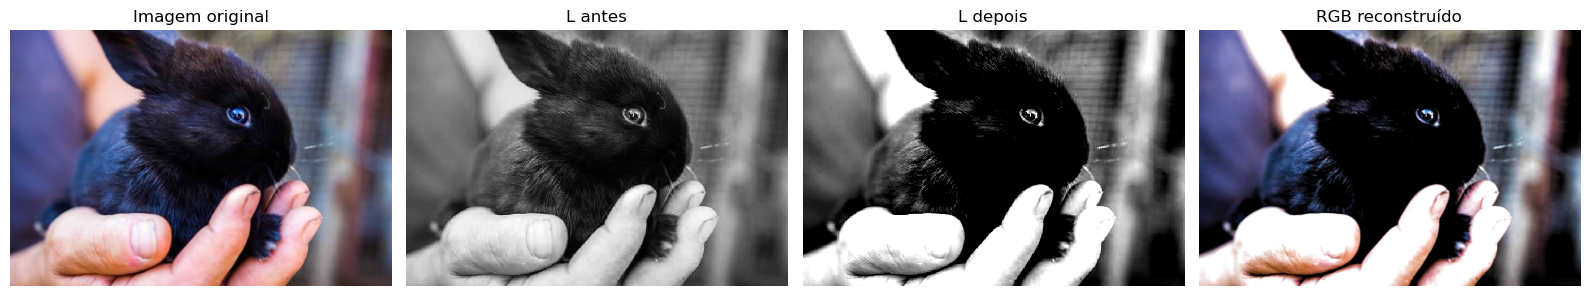

Intervalo L antes: [0.000, 0.994]
Intervalo L depois: [0.000, 1.000]


In [11]:
exibir_paineis([
    (imagem_original, "Imagem original", None),
    (l_antes, "L antes", 1),
    (l_depois, "L depois", 1),
    (imagem_resultante, "RGB reconstruído", None),
])

print(f"Intervalo L antes: [{l_antes.min():.3f}, {l_antes.max():.3f}]")
print(f"Intervalo L depois: [{l_depois.min():.3f}, {l_depois.max():.3f}]")

###### 6.

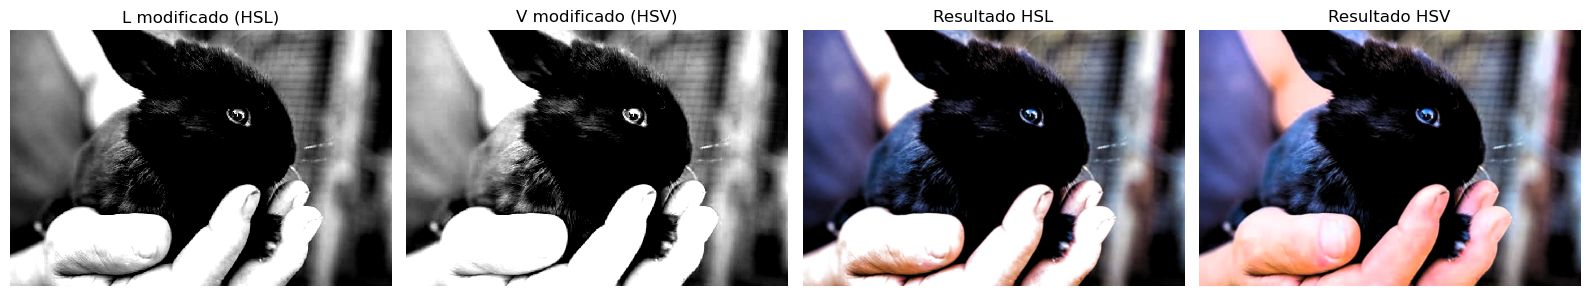

Diferença absoluta média entre saídas RGB (escala 0–1): 0.0533


In [12]:
hsv_original = rgb_to_hsv(rgb_original)
v_antes, v_depois, hsv_modificado, resultado_hsv = contrastar_espaco(
    hsv_original, hsv_to_rgb
)
imagem_hsv = rgb_float_para_imagem(resultado_hsv)
imagem_hsv.save("questao2_contraste_hsv.png")

exibir_paineis([
    (l_depois, "L modificado (HSL)", 1),
    (v_depois, "V modificado (HSV)", 1),
    (imagem_resultante, "Resultado HSL", None),
    (imagem_hsv, "Resultado HSV", None),
])

mae = np.mean(np.abs(rgb_resultante - resultado_hsv))
print(f"Diferença absoluta média entre saídas RGB (escala 0–1): {mae:.4f}")

##### Questão3 

###### 1

In [13]:
largura = altura = 100
x = np.arange(largura)
y = np.arange(altura)
X, Y = np.meshgrid(x, y)


def avaliar_funcao(a=1, b=1, h=50, k=50, c=0):
    """Avalia a família de funções no domínio discreto de 100 × 100."""
    return a * (X - h)**2 + b * (Y - k)**2 + c


def desenhar_superficie(eixo, valores, titulo, elevacao=30, azimute=-60):
    """Desenha a superfície 3D da função."""
    superficie = eixo.plot_surface(
        X, Y, valores, cmap="viridis", linewidth=0, rcount=50, ccount=50
    )
    eixo.view_init(elev=elevacao, azim=azimute)
    eixo.set(title=titulo, xlabel="x", ylabel="y", zlabel="f(x, y)")
    return superficie


def gerar_bitmap_cinza(canal_normalizado):
    return np.rint(canal_normalizado * 255).astype(np.uint8)


matriz = avaliar_funcao()

f_min, f_max = matriz.min(), matriz.max()
normalizada = normalizar_canal(matriz)
matriz_uint8 = gerar_bitmap_cinza(normalizada)
imagem_funcao = Image.fromarray(matriz_uint8)
imagem_funcao.save("questao3_funcao_cinza.png")

assert matriz.shape == (100, 100)
assert matriz[50, 50] == 0
assert matriz_uint8.min() == 0 and matriz_uint8.max() == 255
print(f"Matriz: {matriz.shape} | f mínimo={f_min} | f máximo={f_max}")

Matriz: (100, 100) | f mínimo=0 | f máximo=5000


###### 2.

In [14]:
# Duas tabelas completas, com as coordenadas de cada pixel como rótulos.
indice_y = pd.Index(y, name="y")
colunas_x = pd.Index(x, name="x")
df_funcao = pd.DataFrame(matriz, index=indice_y, columns=colunas_x)
df_bitmap = pd.DataFrame(matriz_uint8, index=indice_y, columns=colunas_x)

for titulo, quadro in [
    ("Matriz da função f(x, y)", df_funcao),
    ("Bitmap em cinza (0–255)", df_bitmap),
]:
    display(HTML(
        f"<h4>{titulo}</h4>"
        '<div style="max-height:360px;max-width:100%;overflow:auto;'
        'border:1px solid #aaa;padding:8px">'
        + quadro.to_html(max_rows=100, max_cols=100)
        + '</div>'
    ))

x,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
y,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,5000,4901,4804,4709,4616,4525,4436,4349,4264,4181,4100,4021,3944,3869,3796,3725,3656,3589,3524,3461,3400,3341,3284,3229,3176,3125,3076,3029,2984,2941,2900,2861,2824,2789,2756,2725,2696,2669,2644,2621,2600,2581,2564,2549,2536,2525,2516,2509,2504,2501,2500,2501,2504,2509,2516,2525,2536,2549,2564,2581,2600,2621,2644,2669,2696,2725,2756,2789,2824,2861,2900,2941,2984,3029,3076,3125,3176,3229,3284,3341,3400,3461,3524,3589,3656,3725,3796,3869,3944,4021,4100,4181,4264,4349,4436,4525,4616,4709,4804,4901
1,4901,4802,4705,4610,4517,4426,4337,4250,4165,4082,4001,3922,3845,3770,3697,3626,3557,3490,3425,3362,3301,3242,3185,3130,3077,3026,2977,2930,2885,2842,2801,2762,2725,2690,2657,2626,2597,2570,2545,2522,2501,2482,2465,2450,2437,2426,2417,2410,2405,2402,2401,2402,2405,2410,2417,2426,2437,2450,2465,2482,2501,2522,2545,2570,2597,2626,2657,2690,2725,2762,2801,2842,2885,2930,2977,3026,3077,3130,3185,3242,3301,3362,3425,3490,3557,3626,3697,3770,3845,3922,4001,4082,4165,4250,4337,4426,4517,4610,4705,4802
2,4804,4705,4608,4513,4420,4329,4240,4153,4068,3985,3904,3825,3748,3673,3600,3529,3460,3393,3328,3265,3204,3145,3088,3033,2980,2929,2880,2833,2788,2745,2704,2665,2628,2593,2560,2529,2500,2473,2448,2425,2404,2385,2368,2353,2340,2329,2320,2313,2308,2305,2304,2305,2308,2313,2320,2329,2340,2353,2368,2385,2404,2425,2448,2473,2500,2529,2560,2593,2628,2665,2704,2745,2788,2833,2880,2929,2980,3033,3088,3145,3204,3265,3328,3393,3460,3529,3600,3673,3748,3825,3904,3985,4068,4153,4240,4329,4420,4513,4608,4705
3,4709,4610,4513,4418,4325,4234,4145,4058,3973,3890,3809,3730,3653,3578,3505,3434,3365,3298,3233,3170,3109,3050,2993,2938,2885,2834,2785,2738,2693,2650,2609,2570,2533,2498,2465,2434,2405,2378,2353,2330,2309,2290,2273,2258,2245,2234,2225,2218,2213,2210,2209,2210,2213,2218,2225,2234,2245,2258,2273,2290,2309,2330,2353,2378,2405,2434,2465,2498,2533,2570,2609,2650,2693,2738,2785,2834,2885,2938,2993,3050,3109,3170,3233,3298,3365,3434,3505,3578,3653,3730,3809,3890,3973,4058,4145,4234,4325,4418,4513,4610
4,4616,4517,4420,4325,4232,4141,4052,3965,3880,3797,3716,3637,3560,3485,3412,3341,3272,3205,3140,3077,3016,2957,2900,2845,2792,2741,2692,2645,2600,2557,2516,2477,2440,2405,2372,2341,2312,2285,2260,2237,2216,2197,2180,2165,2152,2141,2132,2125,2120,2117,2116,2117,2120,2125,2132,2141,2152,2165,2180,2197,2216,2237,2260,2285,2312,2341,2372,2405,2440,2477,2516,2557,2600,2645,2692,2741,2792,2845,2900,2957,3016,3077,3140,3205,3272,3341,3412,3485,3560,3637,3716,3797,3880,3965,4052,4141,4232,4325,4420,4517
5,4525,4426,4329,4234,4141,4050,3961,3874,3789,3706,3625,3546,3469,3394,3321,3250,3181,3114,3049,2986,2925,2866,2809,2754,2701,2650,2601,2554,2509,2466,2425,2386,2349,2314,2281,2250,2221,2194,2169,2146,2125,2106,2089,2074,2061,2050,2041,2034,2029,2026,2025,2026,2029,2034,2041,2050,2061,2074,2089,2106,2125,2146,2169,2194,2221,2250,2281,2314,2349,2386,2425,2466,2509,2554,2601,2650,2701,2754,2809,2866,2925,2986,3049,3114,3181,3250,3321,3394,3469,3546,3625,3706,3789,3874,3961,4050,4141,4234,4329,4426
6,4436,4337,4240,4145,4052,3961,3872,3785,3700,3617,3536,3457,3380,3305,3232,3161,3092,3025,2960,2897,2836,2777,2720,2665,2612,2561,2512,2465,2420,2377,2336,2297,2260,2225,2192,2161,2132,2105,2080,2057,2036,2017,2000,1985,1972,1961,1952,1945,1940,1937,1936,1937,1940,1945,1952,1961,1972,1985,2000,2017,2036,2057,2080,2105,2132,2161,2192,2225,2260,2297,2336,2377,2420,2465,2512,2561,2612,2665,2720,2777,2836,2897,2960,3025,3092,3161,3232,3305,3380,3457,3536,3617,3700,3785,3872,3961,4052,4145,4240,4337
7,4349,4250,4153,4058,3965,3874,3785,3698,3613,3530,3449,3370,3293,3218,3145,3074,3005,2938,

x,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
y,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,255,250,245,240,235,231,226,222,217,213,209,205,201,197,194,190,186,183,180,177,173,170,167,165,162,159,157,154,152,150,148,146,144,142,141,139,137,136,135,134,133,132,131,130,129,129,128,128,128,128,128,128,128,128,128,129,129,130,131,132,133,134,135,136,137,139,141,142,144,146,148,150,152,154,157,159,162,165,167,170,173,177,180,183,186,190,194,197,201,205,209,213,217,222,226,231,235,240,245,250
1,250,245,240,235,230,226,221,217,212,208,204,200,196,192,189,185,181,178,175,171,168,165,162,160,157,154,152,149,147,145,143,141,139,137,136,134,132,131,130,129,128,127,126,125,124,124,123,123,123,123,122,123,123,123,123,124,124,125,126,127,128,129,130,131,132,134,136,137,139,141,143,145,147,149,152,154,157,160,162,165,168,171,175,178,181,185,189,192,196,200,204,208,212,217,221,226,230,235,240,245
2,245,240,235,230,225,221,216,212,207,203,199,195,191,187,184,180,176,173,170,167,163,160,157,155,152,149,147,144,142,140,138,136,134,132,131,129,128,126,125,124,123,122,121,120,119,119,118,118,118,118,118,118,118,118,118,119,119,120,121,122,123,124,125,126,128,129,131,132,134,136,138,140,142,144,147,149,152,155,157,160,163,167,170,173,176,180,184,187,191,195,199,203,207,212,216,221,225,230,235,240
3,240,235,230,225,221,216,211,207,203,198,194,190,186,182,179,175,172,168,165,162,159,156,153,150,147,145,142,140,137,135,133,131,129,127,126,124,123,121,120,119,118,117,116,115,114,114,113,113,113,113,113,113,113,113,113,114,114,115,116,117,118,119,120,121,123,124,126,127,129,131,133,135,137,140,142,145,147,150,153,156,159,162,165,168,172,175,179,182,186,190,194,198,203,207,211,216,221,225,230,235
4,235,230,225,221,216,211,207,202,198,194,190,185,182,178,174,170,167,163,160,157,154,151,148,145,142,140,137,135,133,130,128,126,124,123,121,119,118,117,115,114,113,112,111,110,110,109,109,108,108,108,108,108,108,108,109,109,110,110,111,112,113,114,115,117,118,119,121,123,124,126,128,130,133,135,137,140,142,145,148,151,154,157,160,163,167,170,174,178,182,185,190,194,198,202,207,211,216,221,225,230
5,231,226,221,216,211,207,202,198,193,189,185,181,177,173,169,166,162,159,155,152,149,146,143,140,138,135,133,130,128,126,124,122,120,118,116,115,113,112,111,109,108,107,107,106,105,105,104,104,103,103,103,103,103,104,104,105,105,106,107,107,108,109,111,112,113,115,116,118,120,122,124,126,128,130,133,135,138,140,143,146,149,152,155,159,162,166,169,173,177,181,185,189,193,198,202,207,211,216,221,226
6,226,221,216,211,207,202,197,193,189,184,180,176,172,169,165,161,158,154,151,148,145,142,139,136,133,131,128,126,123,121,119,117,115,113,112,110,109,107,106,105,104,103,102,101,101,100,100,99,99,99,99,99,99,99,100,100,101,101,102,103,104,105,106,107,109,110,112,113,115,117,119,121,123,126,128,131,133,136,139,142,145,148,151,154,158,161,165,169,172,176,180,184,189,193,197,202,207,211,216,221
7,222,217,212,207,202,198,193,189,184,180,176,172,168,164,160,157,153,150,147,143,140,137,134,131,129,126,124,121,119,117,115,113,111,109,107,106,104,103,102,100,99,98,98,97,96,96,95,95,95,94,94,94,95,95,95,96,96,97,98,98,99,100,102,103,104,106,107,109,111,113,115,117,119,121,124,126,129,131,134,137,140,143,147,150,153,157,160,164,168,172,176,180,184,189,193,198,202,207,212,217
8,217,212,207,203,198,193,189,184,180,176,172,168,164,160,156,152,149,146,142,139,136,133,130,127,124,122,119,117,115,112,110,108,106,105,103,101,100,99,97,96,95,94,93,92,92,91,91,90,90,90,90,90,90,90,91,91,92,92,93,94,95,96,97,99,100,101,103,105,106,108,110,112,115,117,119,122,124,127,130,133,136,139,142,146,149,152,156,160,164,168,172,176,180,184,189,193,198,203,207,212


###### 3.
O gráfico começa com $f(x,y)=(x-50)^2+(y-50)^2$. Os controles abaixo alteram a imagem e a superfície 3D; Reproduzir move o centro no eixo x. Os PNGs salvos continuam representando a função original.

In [15]:
def mostrar_funcao_interativa(a, b, h, k, c, elevacao, azimute):
    valores = avaliar_funcao(a, b, h, k, c)
    pixels = gerar_bitmap_cinza(normalizar_canal(valores))

    fig = plt.figure(figsize=(13, 5))
    eixo_img = fig.add_subplot(1, 2, 1)
    exibir_imagem(eixo_img, pixels, "Bitmap recalculado (0–255)", 255, True)

    eixo_3d = fig.add_subplot(1, 2, 2, projection="3d")
    superficie = desenhar_superficie(
        eixo_3d, valores,
        f"a={a:.1f}, b={b:.1f}, h={h}, k={k}, c={c:.0f}",
        elevacao, azimute,
    )
    fig.colorbar(superficie, ax=eixo_3d, shrink=0.65, pad=0.12)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


controles = {
    "a": widgets.FloatSlider(value=1, min=-2, max=2, step=0.1,
                             description="a", continuous_update=False),
    "b": widgets.FloatSlider(value=1, min=-2, max=2, step=0.1,
                             description="b", continuous_update=False),
    "h": widgets.IntSlider(value=50, min=0, max=99,
                           description="h", continuous_update=False),
    "k": widgets.IntSlider(value=50, min=0, max=99,
                           description="k", continuous_update=False),
    "c": widgets.FloatSlider(value=0, min=-5000, max=5000, step=100,
                             description="c", continuous_update=False),
    "elevacao": widgets.IntSlider(value=30, min=0, max=90,
                                  description="Elevação", continuous_update=False),
    "azimute": widgets.IntSlider(value=-60, min=-180, max=180,
                                 description="Azimute", continuous_update=False),
}

reproduzir = widgets.Play(value=50, min=0, max=99, step=1, interval=400,
                         description="Reproduzir")
ligacao_reproducao = widgets.link((reproduzir, "value"), (controles["h"], "value"))
saida_interativa = widgets.interactive_output(mostrar_funcao_interativa, controles)
painel_controles = widgets.VBox([
    widgets.HBox([controles["a"], controles["b"], controles["c"]]),
    widgets.HBox([reproduzir, controles["h"], controles["k"]]),
    widgets.HBox([controles["elevacao"], controles["azimute"]]),
])
display(painel_controles, saida_interativa)

Output()

###### 4.

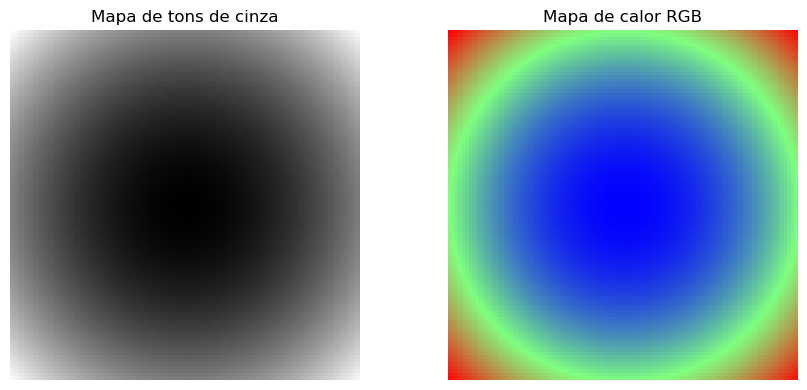

Imagem colorida salva: questao3_mapa_calor_rgb.png


In [16]:
u = normalizada
vermelho = np.clip(u, 0, 1)
verde = np.clip(1 - np.abs(2*u - 1), 0, 1)
azul = np.clip(1 - u, 0, 1)
imagem_calor = rgb_float_para_imagem(
    np.stack([vermelho, verde, azul], axis=-1)
)
imagem_calor.save("questao3_mapa_calor_rgb.png")

exibir_paineis([
    (imagem_funcao, "Mapa de tons de cinza", 255),
    (imagem_calor, "Mapa de calor RGB", None),
], figsize=(9, 4))
print("Imagem colorida salva: questao3_mapa_calor_rgb.png")

##### Questão4

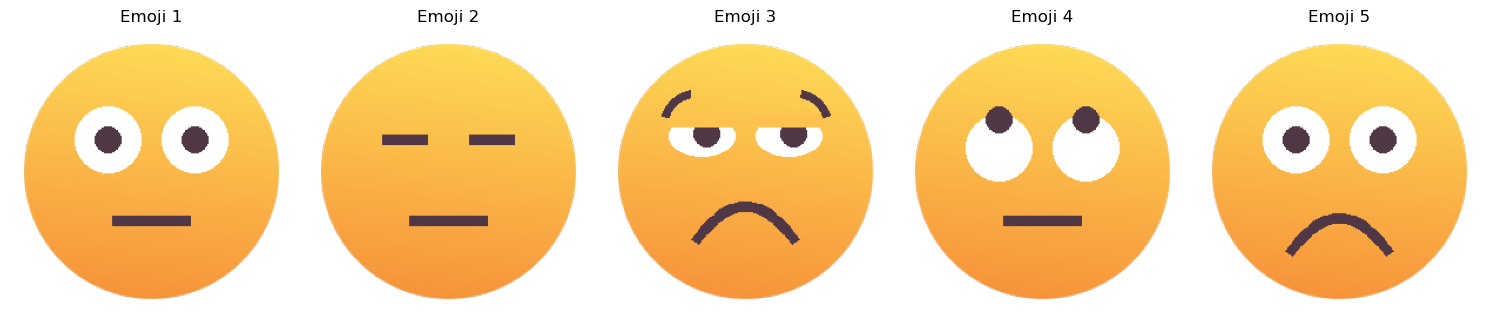

Cinco emojis gerados e salvos em questao4_emojis.png


In [49]:
def criar_emoji(
    tamanho=240,
    abertura_olhos=1.0,
    altura_olhos=93,
    olhar_x=0.0,
    olhar_y=0.0,
    sobrancelhas=0.0,
    curvatura_boca=0.0,
    abertura_boca=0.0,
    altura_boca=162,
    largura_boca=66,
    cor_topo=(255, 227, 89),
    cor_base=(246, 135, 54),
    cor_tracos=(79, 55, 69),
):
    """Desenha um rosto circular; valores contínuos permitem outras expressões.

    Aberturas e sobrancelhas: 0–1. Olhar e curvatura: -1–1.
    Curvatura negativa cria boca triste; positiva cria sorriso.
    """
    if not isinstance(tamanho, int) or tamanho < 32:
        raise ValueError("tamanho deve ser um inteiro de pelo menos 32 pixels")

    limites = {
        "abertura_olhos": (abertura_olhos, 0, 1),
        "altura_olhos": (altura_olhos, 60, 120),
        "olhar_x": (olhar_x, -1, 1),
        "olhar_y": (olhar_y, -1, 1),
        "sobrancelhas": (sobrancelhas, 0, 1),
        "curvatura_boca": (curvatura_boca, -1, 1),
        "abertura_boca": (abertura_boca, 0, 1),
        "altura_boca": (altura_boca, 140, 200),
        "largura_boca": (largura_boca, 30, 100),
    }
    for nome, (valor, minimo, maximo) in limites.items():
        try:
            valido = bool(np.isfinite(valor) and minimo <= valor <= maximo)
        except (TypeError, ValueError):
            valido = False
        if not valido:
            raise ValueError(f"{nome} deve estar entre {minimo} e {maximo}")

    for nome, cor in {"cor_topo": cor_topo, "cor_base": cor_base,
                      "cor_tracos": cor_tracos}.items():
        if (not isinstance(cor, (tuple, list)) or len(cor) != 3
                or any(not isinstance(v, int) or not 0 <= v <= 255 for v in cor)):
            raise ValueError(f"{nome} deve ter três inteiros RGB de 0 a 255")

    escala = tamanho / 240
    imagem = Image.new("RGBA", (tamanho, tamanho), (0, 0, 0, 0))

    # Rosto em degradê, calculado numa base de 240 × 240 e escalado.
    yy, xx = np.mgrid[0:tamanho, 0:tamanho]
    distancia = np.sqrt((xx - 120*escala)**2 + (yy - 120*escala)**2)
    mistura = np.clip((yy / (tamanho - 1)) * 0.85
                      + (1 - xx / (tamanho - 1)) * 0.10, 0, 1)
    topo = np.asarray(cor_topo, dtype=float)
    base = np.asarray(cor_base, dtype=float)
    face = topo * (1 - mistura[..., None]) + base * mistura[..., None]
    alfa = np.clip((109*escala - distancia) / max(1.2*escala, 1e-8), 0, 1) * 255
    pixels = np.dstack([face.astype(np.uint8), alfa.astype(np.uint8)])
    imagem = Image.alpha_composite(imagem, Image.fromarray(pixels, "RGBA"))
    pincel = ImageDraw.Draw(imagem)

    def caixa(x1, y1, x2, y2):
        return tuple(round(v*escala) for v in (x1, y1, x2, y2))

    def pontos(coordenadas):
        return [tuple(round(v*escala) for v in ponto) for ponto in coordenadas]

    escuro = tuple(cor_tracos) + (255,)
    branco = (255, 255, 255, 255)
    largura = max(1, round(9*escala))

    # Abertura zero desenha olhos em traços; valores maiores abrem as pálpebras.
    for centro_x in (83, 157):
        if abertura_olhos == 0:
            pincel.line(pontos([(centro_x-19, altura_olhos),
                                (centro_x+19, altura_olhos)]),
                        fill=escuro, width=largura)
            continue

        meia_altura = 28 * abertura_olhos
        pincel.ellipse(caixa(centro_x-28, altura_olhos-meia_altura,
                            centro_x+28, altura_olhos+meia_altura), fill=branco)
        pupila_x = centro_x + 10*olhar_x
        pupila_y = altura_olhos + 24*olhar_y
        raio_x = 11
        raio_y = min(11, max(5, 20*abertura_olhos))
        pincel.ellipse(caixa(pupila_x-raio_x, pupila_y-raio_y,
                            pupila_x+raio_x, pupila_y+raio_y), fill=escuro)

        if abertura_olhos < 0.8:
            palpebra_y = altura_olhos - 0.8*meia_altura
            pincel.line(pontos([(centro_x-29, palpebra_y),
                                (centro_x+29, palpebra_y)]),
                        fill=(255, 194, 78, 255),
                        width=max(1, round(10*escala)))

    if sobrancelhas > 0:
        largura_sobrancelha = max(1, round(7*escala*sobrancelhas))
        pincel.arc(caixa(47, 51, 107, 117), start=200, end=262,
                   fill=escuro, width=largura_sobrancelha)
        pincel.arc(caixa(134, 51, 194, 117), start=278, end=340,
                   fill=escuro, width=largura_sobrancelha)

    if abertura_boca > 0:
        centro_y = altura_boca + 17 + 12*curvatura_boca
        largura_aberta = largura_boca * (0.55 + 0.2*abertura_boca)
        altura_aberta = max(4, 49*abertura_boca)
        pincel.ellipse(caixa(120-largura_aberta/2, centro_y-altura_aberta/2,
                            120+largura_aberta/2, centro_y+altura_aberta/2),
                       fill=escuro)
        if abertura_boca > 0.5:
            pincel.arc(caixa(101, centro_y+1, 143, centro_y+32),
                       start=180, end=350, fill=(195, 84, 102, 255),
                       width=max(2, round(5*escala)))
    else:
        curva = [
            (x, altura_boca + 30*curvatura_boca*(1 - ((x-120)/(largura_boca/2))**2))
            for x in np.linspace(120-largura_boca/2, 120+largura_boca/2, 23)
        ]
        pincel.line(pontos(curva), fill=escuro, width=largura, joint="curve")

    return imagem


# Cinco chamadas independentes reproduzem as referências; outras combinações
# podem ser criadas chamando criar_emoji com novos valores.
emojis = [
    criar_emoji(),
    criar_emoji(abertura_olhos=0),
    criar_emoji(abertura_olhos=0.6, altura_olhos=90, olhar_x=0.4, olhar_y=-0.10,
                sobrancelhas=1, altura_boca=180, largura_boca=86, curvatura_boca=-1),
    criar_emoji(altura_olhos=100, olhar_y=-1),
    criar_emoji(curvatura_boca=-1, altura_boca=190, largura_boca=86),
]

montagem = Image.new("RGBA", (5*240, 240), (255, 255, 255, 255))
for indice, emoji in enumerate(emojis):
    montagem.alpha_composite(emoji, (indice * 240, 0))
montagem.convert("RGB").save("questao4_emojis.png")

exibir_paineis(
    [(emoji, f"Emoji {numero}", None)
     for numero, emoji in enumerate(emojis, start=1)],
    figsize=(15, 3.5),
)
print("Cinco emojis gerados e salvos em questao4_emojis.png")